<a href="https://colab.research.google.com/github/andysongyz-dev/brown-summer/blob/main/Team4_Spotify_Rec_1_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spotify Recommendation Engine

### Objective

The objective is to use recommendation engines through different data processing techniques. We also want to incorporate user feedback to personalize this recommendation engine. We want to recommend songs and include an interactive prompt after in order to receive user feedback for improvement.

### 1. Libraries

In [1]:
#import libraries

import pandas as pd
from sklearn.cluster import KMeans

### 2. Data Cleaning & Exploration

In [2]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#import data and check

tracks_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/spotify_tracks.csv")

tracks_df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
#dimensions
print(f"rows, columns: {tracks_df.shape}")

rows, columns: (114000, 21)


In [5]:
#column names
print(tracks_df.columns.tolist())

['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [6]:
#describe the dataset
tracks_df.describe()


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [7]:
tracks_df['instrumentalness'].value_counts()

,count
instrumentalness,
0.000000,38763
0.000036,166
0.905000,122
0.895000,122
0.934000,121
...,...
0.000065,1
0.000098,1
0.000071,1


In [8]:
tracks_df['acousticness'].value_counts()

,count
acousticness,
0.995000,305
0.993000,267
0.994000,266
0.992000,250
0.991000,218
...,...
0.000063,1
0.000021,1
0.000004,1


In [9]:
#check dataset for missing values
import numpy as np
tracks_df = tracks_df.replace("unknown", np.nan)

In [10]:
#reveal important missing na values
tracks_df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,2
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [11]:
#view any 0's that could be NA values
zeros_column = (tracks_df == 0).sum()

print(zeros_column[zeros_column > 0])

Unnamed: 0               1
popularity           16020
duration_ms              1
explicit            104253
danceability           157
energy                   1
key                  13061
mode                 41319
speechiness            157
acousticness            39
instrumentalness     38763
liveness                 2
valence                176
tempo                  157
time_signature         163
dtype: int64


In [12]:
#replace appropriate NA/0 values with -99 as an outlier

columns_clean = [
    'acousticness', 'instrumentalness'
]


tracks_df[columns_clean] = tracks_df[columns_clean].replace(0, -99)

In [13]:
#double check
tracks_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113998 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

Create visualizations

In [14]:
#import libraries
import matplotlib.pyplot as plt
import seaborn as sns

#choose features we want
features_to_plot = [
    'popularity', 'danceability', 'energy', 'loudness', 'acousticness',
    'instrumentalness', 'valence', 'tempo'
]

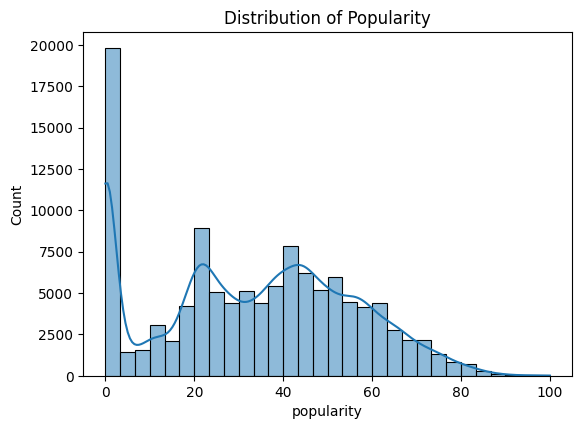

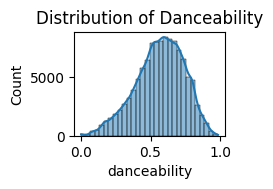

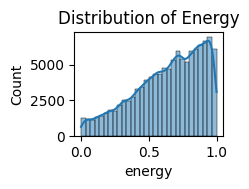

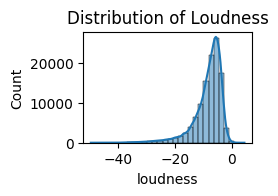

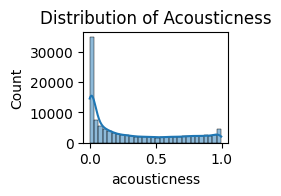

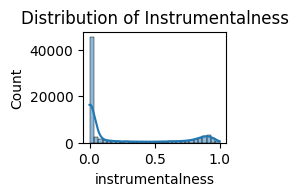

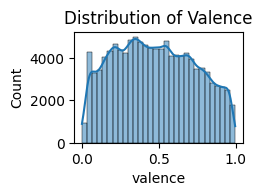

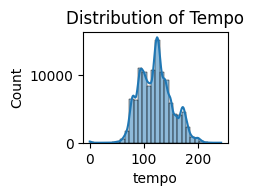

In [15]:
#create histogram

plt.figure(figsize=(16,12))

for i, col in enumerate(features_to_plot, 1):
  plt.subplot(3, 3, i)

  #remove -99 from the graphs
  filtered_data = tracks_df[tracks_df[col] !=-99]

  sns.histplot(data=filtered_data, x=col, kde=True, bins=30)
  plt.title(f'Distribution of {col.title()}')
  plt.xlabel(col)
  plt.ylabel('Count')

  plt.tight_layout()
  plt.show()

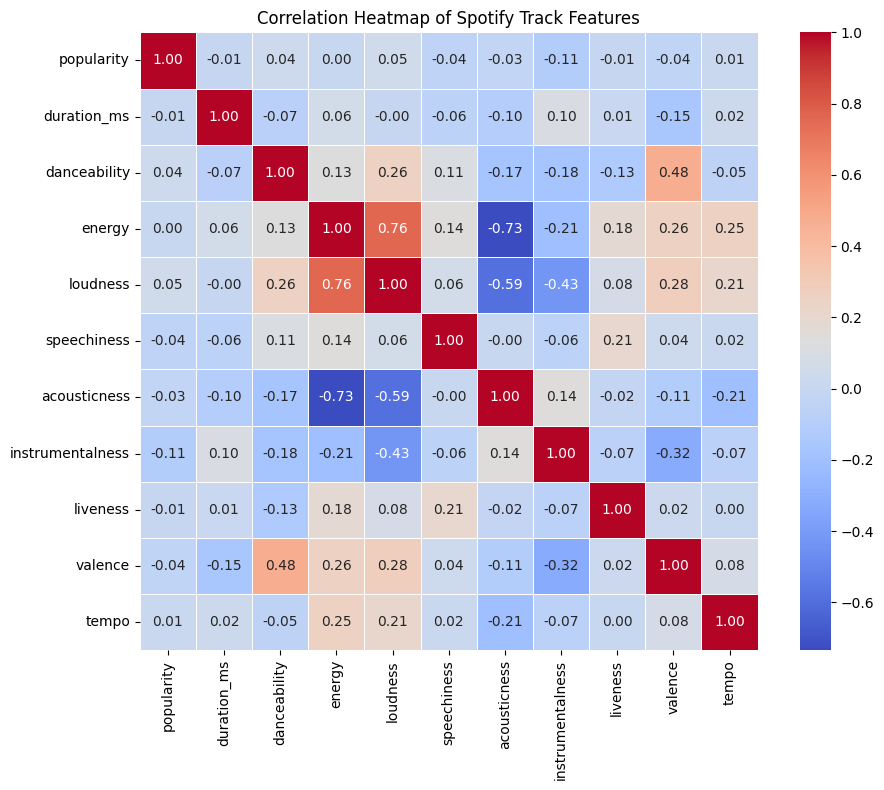

In [16]:
# Correlation heatmap

numerical_features = [
    'popularity', 'duration_ms', 'danceability', 'energy',
    'loudness', 'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo'
]

temp_df = tracks_df[numerical_features].copy()

temp_df = temp_df.replace([-99, -99.0], np.nan)

#matrix
corr_matrix = temp_df.corr()

#plot
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Spotify Track Features')
plt.tight_layout()
plt.show()


### 3. Model Enhancement

In [17]:
#check -99 rows

(tracks_df[['instrumentalness','acousticness']] == -99).sum()

#remove rows containing -99

tracks_df_cleans = tracks_df[
    (tracks_df['instrumentalness'] != -99)&
    (tracks_df['acousticness'] != -99)
]

#check again

(tracks_df_cleans[['instrumentalness','acousticness']] == -99).sum()

,0
instrumentalness,0
acousticness,0


In [18]:
import pandas as pd
import numpy as np

#remove rows containing -99
tracks_df_cleans = tracks_df[
    (tracks_df['instrumentalness'] != -99)&
    (tracks_df['acousticness'] != -99)
]

#define features
audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo'
]

# Prepare the features
spotify_feature = tracks_df_cleans[audio_features]
display(spotify_feature.head())

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.7150,87.917
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.2670,77.489
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.1430,181.740
6,0.407,0.1470,-8.822,0.0355,0.8570,0.000003,0.0913,0.0765,141.284
9,0.442,0.6320,-6.770,0.0295,0.4260,0.004190,0.0735,0.1960,78.899


In [19]:
from sklearn.preprocessing import StandardScaler

# Calculate IQR and filter outliers
Q1 = spotify_feature.quantile(0.25)
Q3 = spotify_feature.quantile(0.75)
IQR = Q3 - Q1

filtered_df = spotify_feature[
    ~((spotify_feature < (Q1 - 1.5 * IQR)) |
      (spotify_feature > (Q3 + 1.5 * IQR))).any(axis=1)].copy()

print(f"Before removing outliers: {spotify_feature.shape}")
print(f"After removing outliers: {filtered_df.shape}")

# Scale the filtered data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(filtered_df)

Before removing outliers: (75202, 9)
After removing outliers: (58707, 9)


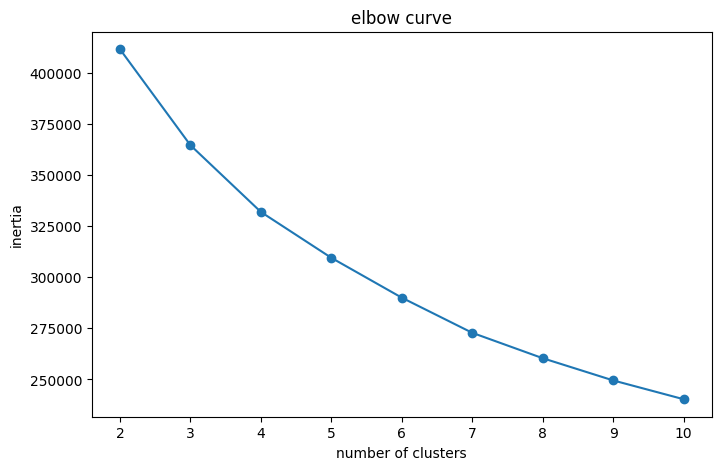

In [20]:
#test different cluster numbers

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Scale the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(filtered_df)

inertia = []

for k in range(2,11):

  kmeans = KMeans (
      n_clusters=k,
      random_state=42,
      n_init=10
  )

  kmeans.fit(scaled_features)
  inertia.append(kmeans.inertia_)

#plot elbow curve

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel("number of clusters")
plt.ylabel("inertia")
plt.title("elbow curve")

plt.show()

K-Means Clustering:

In [21]:
from sklearn.cluster import KMeans

# K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(scaled_features)

# Add labels to the filtered dataframe
filtered_df['cluster'] = kmeans_labels

# Calculate average features per cluster
cluster_analysis = filtered_df.groupby('cluster').mean()
display(cluster_analysis)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.637940,0.706113,-9.087064,0.053896,0.111075,0.797288,0.126608,0.358428,124.304328
1,0.674353,0.698987,-6.972031,0.049030,0.204508,0.031899,0.115131,0.622346,117.030151
2,0.438011,0.854125,-5.322044,0.077214,0.057202,0.136630,0.147608,0.348060,145.574880
3,0.477933,0.318813,-12.517904,0.041269,0.746108,0.234508,0.142758,0.311575,111.782897
4,0.563852,0.797100,-6.141381,0.054942,0.129489,0.111071,0.337994,0.518442,124.332771


Agglomerative Clustering:

In [22]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import pandas as pd

# To prevent RAM crashes, we use smaller size data
sample_size = min(2000, len(scaled_features))
np.random.seed(42)
sample_indices = np.random.choice(len(scaled_features), sample_size, replace=False)
scaled_sample = scaled_features[sample_indices]

print(f"Running Agglomerative Clustering on {sample_size} cleaned tracks...")

# Agglomerative clustering
agg = AgglomerativeClustering(n_clusters=5)
agg_labels = agg.fit_predict(scaled_sample)

# Display cluster counts
print("\nAgglomerative Cluster Counts (Sample):")
print(pd.Series(agg_labels).value_counts().sort_index())

Running Agglomerative Clustering on 2000 cleaned tracks...

Agglomerative Cluster Counts (Sample):
0    752
1    316
2    553
3    270
4    109
Name: count, dtype: int64


In [23]:
# evaluate agglomerative performance

# calculate silhouette score
from sklearn.metrics import silhouette_score

agg_silhouette = silhouette_score(scaled_sample, agg_labels)
print(f"Agglomerative Silhouette Score: {agg_silhouette}")

Agglomerative Silhouette Score: 0.14217893123043868


In [24]:
# run kmeans with same sample size for fair comparison

kmeans_sample = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_sample_labels = kmeans_sample.fit_predict(scaled_sample)

kmeans_silhouette = silhouette_score(scaled_sample, kmeans_sample_labels)
print(f"K-Means Silhouette Score", kmeans_silhouette)

K-Means Silhouette Score 0.17792809308642998


In [25]:
# comparison table

comparison = pd.DataFrame({
    "Algorithm": ["Agglomerative", "K-Means"],
    "Silhouette Score": [agg_silhouette, kmeans_silhouette]
})

display(comparison)

,Algorithm,Silhouette Score
0,Agglomerative,0.142179
1,K-Means,0.177928


### 4. User Interaction

In [26]:
# Save results and reload for interaction
filtered_df.to_csv("result.csv", index=False)
tracks = pd.read_csv("result.csv")
# Add a unique ID for selection
tracks['UID'] = range(len(tracks))
tracks.head(10)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster,UID
0,0.420,0.1660,-17.235,0.0763,0.924,0.000006,0.1010,0.2670,77.489,3,0
1,0.266,0.0596,-18.515,0.0363,0.905,0.000071,0.1320,0.1430,181.740,3,1
2,0.407,0.1470,-8.822,0.0355,0.857,0.000003,0.0913,0.0765,141.284,3,2
3,0.442,0.6320,-6.770,0.0295,0.426,0.004190,0.0735,0.1960,78.899,3,3
4,0.755,0.7800,-6.084,0.0327,0.124,0.000028,0.1210,0.3870,120.004,1,4
5,0.489,0.5610,-7.933,0.0274,0.200,0.000046,0.1790,0.2380,83.457,1,5
6,0.706,0.1120,-18.098,0.0391,0.827,0.000004,0.1250,0.4140,110.154,3,6
7,0.795,0.0841,-18.090,0.0461,0.742,0.000012,0.0853,0.6090,91.803,3,7
8,0.407,0.1470,-8.822,0.0355,0.857,0.000003,0.0913,0.0765,141.284,3,8
9,0.572,0.4540,-10.286,0.0258,0.477,0.000014,0.0974,0.5150,140.182,3,9


In [27]:
i=0
while i==0:
  print("Song IDs range from 0 to 140000. Any number outside this range will not be added to your favorites.")
  ids = input('Enter comma-separated ids of your favorite songs. Don\'t know your song ID? Type a song name to see its ID.\n> ').strip().split(',')
  try:
    ids = [int(id.strip()) for id in ids]
    print("Entered IDs:", ids)
    favorites = tracks[tracks['UID'].isin(ids)]
    i=1
  except:
    if ids in tracks['track_name'].values:
      songrow = tracks.loc[tracks['track_name'].isin(ids)]
      songid = songrow.iat[0,0]
      songid = str(songid)
      ids = str(ids)
      print("The song ID of " + ids + " is " + songid + ".")
    else:
      print("The name you entered isn't a song in our system.")
favorites


Song IDs range from 0 to 140000. Any number outside this range will not be added to your favorites.
Enter comma-separated ids of your favorite songs. Don't know your song ID? Type a song name to see its ID.
> 0
Entered IDs: [0]


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster,UID
0,0.42,0.166,-17.235,0.0763,0.924,0.000006,0.101,0.267,77.489,3,0


In [28]:
clusters = favorites['cluster'].value_counts()
user_favorite_cluster = clusters.idxmax()
print('\nFavorite cluster:', user_favorite_cluster, '\n')
suggestions = tracks[tracks['cluster'] == user_favorite_cluster]
suggestions.head()


Favorite cluster: 3 



,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster,UID
0,0.420,0.1660,-17.235,0.0763,0.924,0.000006,0.1010,0.2670,77.489,3,0
1,0.266,0.0596,-18.515,0.0363,0.905,0.000071,0.1320,0.1430,181.740,3,1
2,0.407,0.1470,-8.822,0.0355,0.857,0.000003,0.0913,0.0765,141.284,3,2
3,0.442,0.6320,-6.770,0.0295,0.426,0.004190,0.0735,0.1960,78.899,3,3
6,0.706,0.1120,-18.098,0.0391,0.827,0.000004,0.1250,0.4140,110.154,3,6


In [30]:
print("Like these reccomendations? Rate them on a scale of 1 to 5!")
print("1: Poor")
print("2: Fair")
print("3: Good")
print("4: Great")
print("5: Excellent")
feedback = []
suggestions = []
try:
  rating = int(input("Your Rating: "))
  if rating > 0 and rating < 6:
    print("Thanks for your feedback!")
    feedback.append(rating)
  else:
    print("Thanks for your feedback!")
except:
  print("Thanks for your feedback!")
print("Want to make a suggestion? Write it below!")
suggestion = str(input("Suggestion: "))
suggestions.append(suggestion)
print("Thanks!")

Like these reccomendations? Rate them on a scale of 1 to 5!
1: Poor
2: Fair
3: Good
4: Great
5: Excellent
Your Rating: 4
Thanks for your feedback!
Want to make a suggestion? Write it below!
Suggestion: !!
Thanks!
